# Task 2

In [6]:
# Import Qiskit components
from qiskit import QuantumCircuit, transpile, assemble
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

# Use Aer simulator backend
simulator = AerSimulator()

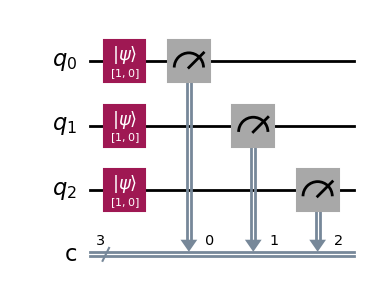

In [19]:
# Create a quantum circuit with 3 qubits and 3 classical bits
qc_a = QuantumCircuit(3, 3)

# Initialize all qubits to |0⟩ (this is default, but we include it explicitly)
qc_a.initialize([1, 0], [0])
qc_a.initialize([1, 0], [1])
qc_a.initialize([1, 0], [2])

# Measure all qubits
qc_a.measure([0, 1, 2], [0, 1, 2])

# Visualize the circuit
qc_a.draw('mpl')

{'000': 1024}


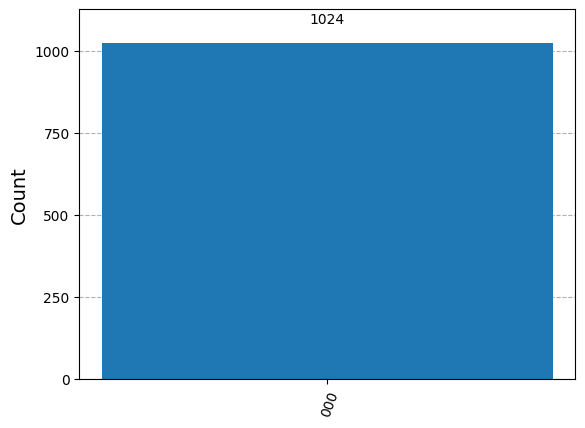

In [9]:
# Run the circuit on the simulator
compiled_circuit = transpile(qc_a, simulator)
sim_result = simulator.run(compiled_circuit).result()
counts_a = sim_result.get_counts()

print(counts_a)

# Display results
plot_histogram(counts_a)

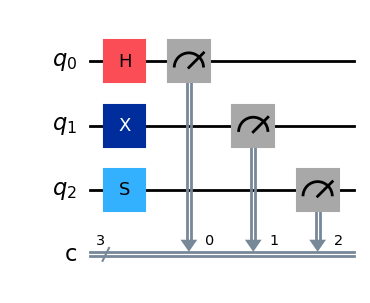

In [13]:
qc_b = QuantumCircuit(3, 3)

# Apply gates
qc_b.h(0)   # Hadamard gate on qubit 0
qc_b.x(1)   # X (NOT) gate on qubit 1
qc_b.s(2)   # S (phase) gate on qubit 2

# Measure all qubits
qc_b.measure([0, 1, 2], [0, 1, 2])

# Visualize the circuit
qc_b.draw('mpl')

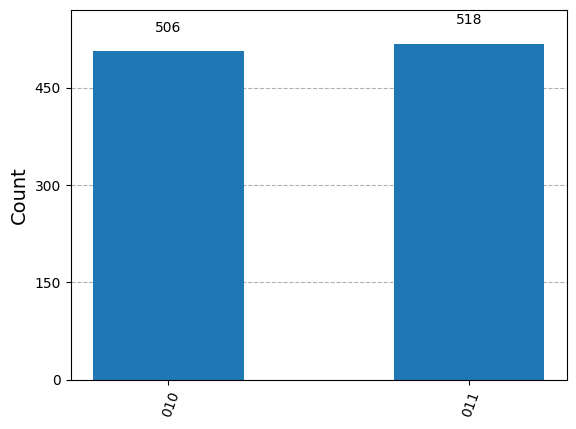

In [ ]:


# %%
# Run the circuit
compiled_circuit = transpile(qc_b, simulator)
sim_result = simulator.run(compiled_circuit).result()
counts_b = sim_result.get_counts()

# Display results
plot_histogram(counts_b)

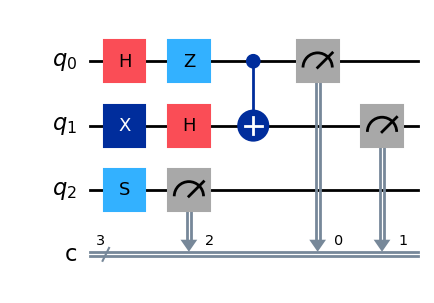

In [11]:
qc_c = QuantumCircuit(3, 3)

# Combine gates
qc_c.h(0)
qc_c.z(0)
qc_c.x(1)
qc_c.h(1)
qc_c.s(2)

# Add controlled operation
qc_c.cx(0, 1)

# Measure all qubits
qc_c.measure([0, 1, 2], [0, 1, 2])

# Visualize the circuit
qc_c.draw('mpl')

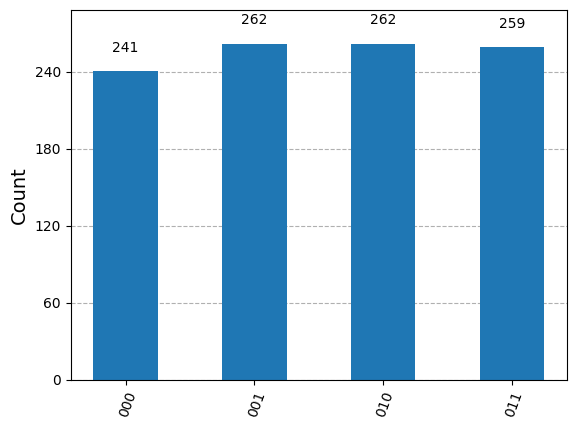

In [12]:
compiled_circuit = transpile(qc_c, simulator)
sim_result = simulator.run(compiled_circuit).result()
counts_c = sim_result.get_counts()

# Display results
plot_histogram(counts_c)

# Task 3 a

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define Pauli matrices
sigma_x = np.array([[0, 1],
                    [1, 0]], dtype=complex)

sigma_y = np.array([[0, -1j],
                    [1j, 0]], dtype=complex)

sigma_z = np.array([[1, 0],
                    [0, -1]], dtype=complex)

H1 = sigma_z
eigvals_H1, eigvecs_H1 = np.linalg.eig(H1)

print("H1 = σz =\n", H1)
print("\nEigenvalues:", eigvals_H1)
print("\nEigenvectors:\n", eigvecs_H1)

H1 = σz =
 [[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

Eigenvalues: [ 1.+0.j -1.+0.j]

Eigenvectors:
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


# Task 3 b

In [27]:
H2 = sigma_x + sigma_z
eigvals_H2, eigvecs_H2 = np.linalg.eig(H2)

# sort eigenvectors by eigenvalues
idx = eigvals_H2.argsort()
eigvals_H2 = eigvals_H2[idx]
eigvecs_H2 = eigvecs_H2[:, idx]

print("H2 = σx + σz =\n", H2)
print("\nEigenvalues:", eigvals_H2)
print("\n eigenvectors:\n", np.round(eigvecs_H2[:, 0], 3))

H2 = σx + σz =
 [[ 1.+0.j  1.+0.j]
 [ 1.+0.j -1.+0.j]]

Eigenvalues: [-1.41421356+0.j  1.41421356+0.j]

 eigenvectors:
 [-0.383+0.j  0.924+0.j]


# Task 3 c

In [ ]:
I = np.eye(2, dtype=complex)

H3 = np.kron(I, sigma_z) + np.kron(sigma_y, I)

eigvals_H3, eigvecs_H3 = np.linalg.eig(H3)

# sort eigenvectors by eigenvalues
idx = eigvals_H3.argsort()
eigvals_H3 = eigvals_H3[idx]
eigvecs_H3 = eigvecs_H3[:, idx]

print("H3 = σy(1) + σz(2) =\n", H3)
print("\nEigenvalues:", np.round(eigvals_H3, 3))
print("\n eigenvectors:\n", np.round(eigvecs_H3[:, 0], 3))

H3 = σy(1) + σz(2) =
 [[ 1.+0.j  0.+0.j  0.-1.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.-1.j]
 [ 0.+1.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+1.j  0.+0.j -1.+0.j]]

Eigenvalues: [-2.+0.j -0.+0.j  0.+0.j  2.+0.j]

Normalized eigenvectors:
 [0.   +0.j    0.   +0.707j 0.   +0.j    0.707+0.j   ]


# Task 3 d

In [22]:
def H4(a, b):
    """Construct H4 = a σx(1) + b σz(2)"""
    return a * np.kron(sigma_x, I) + b * np.kron(I, sigma_z)

# Example: vary a from -2 to 2, with b = 1
a_values = np.linspace(-2, 2, 200)
b_values = np.linspace(-2, 2, 200)

eigvals_list = []
for a in a_values:
    for b in b_values:
        H = H4(a, b)
        eigvals = min(np.linalg.eigvals(H))
        eigvals_list.append(abs(eigvals))
eigvals_array = np.array(eigvals_list)

# %%
# Plot eigenvalues vs a and b as 3d surface using plotly
import plotly.graph_objects as go
X = a_values
Y = b_values
Z = eigvals_array.reshape((len(a_values), len(b_values)))
fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y)])
fig.update_layout(title='Eigenvalue Spectrum vs a and b',
                  scene=dict(
                      xaxis_title='a',
                      yaxis_title='b',
                      zaxis_title='Lowest Eigenvalue'),
                  autosize=True)
fig.show()


# Task 4.1

## a

In [12]:
I = np.eye(2)

H5 = np.kron(I, sigma_x) + np.kron(sigma_x, I)

eigvals_H5, eigvecs_H5 = np.linalg.eig(-1*H5)

# sort eigenvectors according to eigenvalues
idx = eigvals_H5.argsort()
eigvals_H5 = eigvals_H5[idx]
eigvecs_H5 = eigvecs_H5[:, idx]

print("H5 =\n", H5)
print("Lowest Eigenvalues of H5 =\n", eigvals_H5[0])
print("Corresponding Eigenvector of H5 =\n", eigvecs_H5[:,0])


H5 =
 [[0.+0.j 1.+0.j 1.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 1.+0.j 1.+0.j 0.+0.j]]
Lowest Eigenvalues of H5 =
 (-1.9999999999999993+0j)
Corresponding Eigenvector of H5 =
 [0.5-0.j 0.5-0.j 0.5-0.j 0.5+0.j]


## b

The eigenvector corresponding to the lowest eigenvalue of the Hamiltonian represents the ground state of the quantum system. In this example, we compute the eigenvalues and eigenvectors of a simple two-qubit Hamiltonian and identify the ground state.
The lowest energy state is the superposition state  (|00⟩ + |01⟩ + |10⟩ + |11⟩)/2, which is an equal superposition of all possible states of the two qubits. This can be seen by the eigenvector consisting of equal components for each basis state.
The quantum annealer is prepared in this ground state before the annealing process begins.